In [375]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [379]:
ksqrt = np.sqrt(5)
MAE_nicolo = [36.01, 0.14 / ksqrt]  #Initial MAE value from Nicolos simple model BDT
min_nicolo = MAE_nicolo[0] - MAE_nicolo[1]
max_nicolo = MAE_nicolo[0] + MAE_nicolo[1]

MAE_nn = np.array([42.92, 33.66, 31.56, 30.06, 27.37]) 
# | jonas crude | jonas crude .2 more layers | include no zeros | include no zeros w/ h-opt| include no zeros and pictures

MAE_dt = np.array([[28.85, 0.5304 / ksqrt], [23.78, 0.54 / ksqrt], [24.02, 0.32 / ksqrt], [20.11, 0.37 / ksqrt], [20.30, 0.34 / ksqrt], [21.56, 0.36 / ksqrt], [14.73, 0.10 / ksqrt], [13.65, 0.15 / ksqrt]])

xg_dt = np.array([[28.85, 0.5304], [24.227, 0.39 / ksqrt], [24.02, 0.32 / ksqrt], [20.11, 0.37 / ksqrt], [20.30, 0.34 / ksqrt], [13.65, 0.15 / ksqrt]])
lg_dt = np.array([[21.56, 0.36 / ksqrt], [14.73, 0.10 / ksqrt]])
# description in appendix! |1, xgboost (a) no h-opt | 2, xgboost (a) w/ h-opt | 3, xgboost (b) no h-opt | 4, xgboost (b) w/ h-opt | 5, xgboost (c) w/ h-opt | 6. light (c) w/h-opt | 7, light (c) w/h-opt 100 grid | 8, xgboost (c) w/h-opt 100 grid |

def bounds(df, range):
    errors = df[:range, 1]

    lower_bound = df[:range, 0] - errors
    upper_bound = df[:range, 0] + errors
    return lower_bound, upper_bound

errors = MAE_dt[:, 1]

# Calculate the upper and lower bounds for the shaded area
lower_bound = MAE_dt[:, 0] - errors
upper_bound = MAE_dt[:, 0] + errors

#### OLD VALUES ----> np.array(27.5, 23.70, 20.47, 19.60, 7, 20.14, 19.78) 
# | xgboost | lightGBM with optuna | lightgbm with optuna on n0 | xgboost with optuna on n0 better opti | Lightbm no optimization with pics and n0 (OVERFITTED) |

### FIGURES

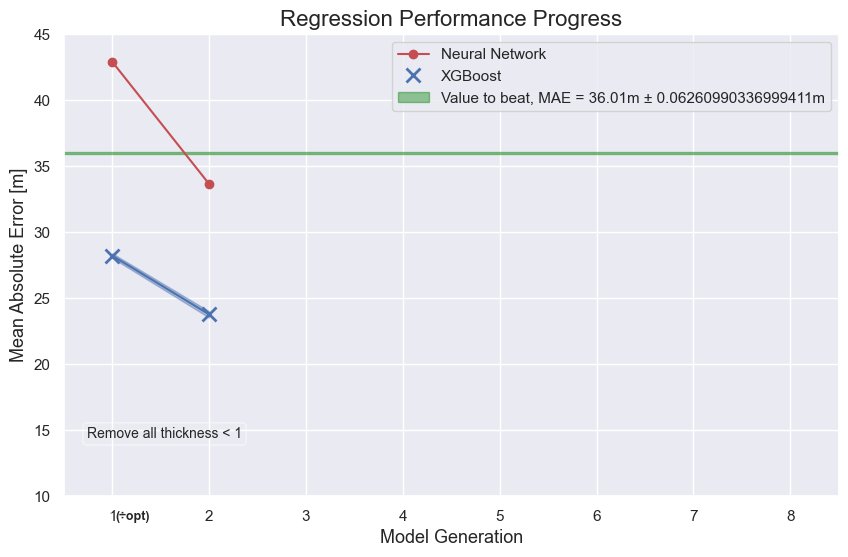

In [378]:
# Plot the measurements
fig, ax = plt.subplots(figsize = (10, 6))

#Neural Network plot
plt.plot((1, 2), MAE_nn[:2],  '-o', label = 'Neural Network', color = 'r')

#XGBoost plot
plt.plot(np.arange(len(MAE_dt[:2, 0])) + 1, MAE_dt[:2, 0], '-', color = 'b')
plt.plot((1, 2), xg_dt[:2, 0], 'x', markersize = 10, markeredgewidth=2, label = 'XGBoost', color = 'b')

plt.fill_between((1, 2), bounds(MAE_dt, 2)[0], bounds(MAE_dt, 2)[1], color='b', alpha=0.4)

# # Use fill_between to create the shaded error area
plt.fill_between(np.linspace(0, 9, 100), min_nicolo, max_nicolo, color='green', alpha=0.4, label = f'Value to beat, MAE = {MAE_nicolo[0]}m \u00B1 {MAE_nicolo[1]}m')

textstr1 = 'Remove all thickness < 1'
props = dict(boxstyle='round', facecolor='none', alpha=0.5)
ax.text(0.03, 0.15, textstr1, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

textstropt = '(÷opt)'
ax.text(0.066, -0.03, textstropt, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props, fontweight='bold')

# Show the plot
plt.legend()
plt.xlim(0.5, 8.5)
plt.ylim(10, 45)
plt.xticks(range(1, len(MAE_dt) + 1))
plt.xlabel('Model Generation', size = 13)
plt.ylabel('Mean Absolute Error [m]', size = 13)
plt.title('Regression Performance Progress', size = 16)
plt.savefig('performance_progress_1.png', dpi = 300);

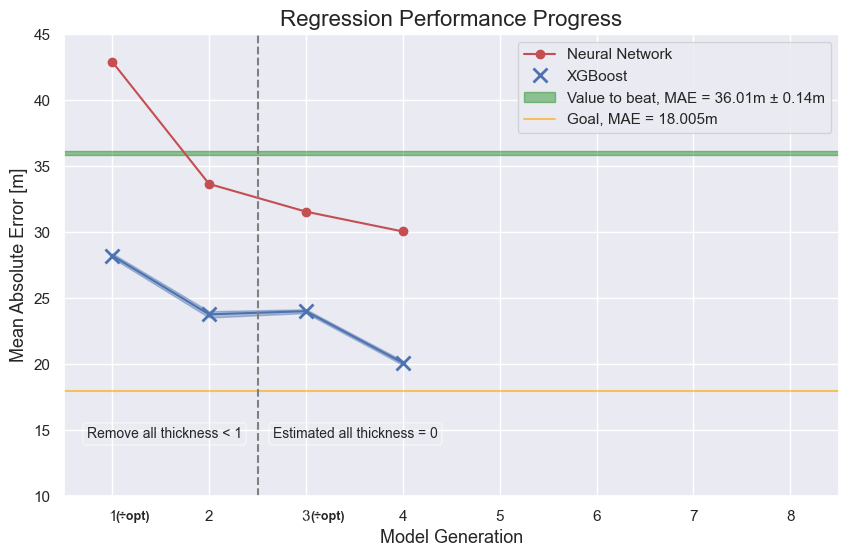

In [ ]:
# Plot the measurements
fig, ax = plt.subplots(figsize = (10, 6))

#Neural Network plot
plt.plot((1, 2, 3, 4), MAE_nn[:4],  '-o', label = 'Neural Network', color = 'r')

#XGBoost plot
plt.plot(np.arange(len(MAE_dt[:4, 0])) + 1, MAE_dt[:4, 0], '-', color = 'b')
plt.plot((1, 2, 3, 4), xg_dt[:4, 0], 'x', markersize = 10, markeredgewidth=2, label = 'XGBoost', color = 'b')

plt.fill_between((1, 2, 3, 4), bounds(MAE_dt, 4)[0], bounds(MAE_dt, 4)[1], color='b', alpha=0.4)

# # Use fill_between to create the shaded error area
plt.fill_between(np.linspace(0, 9, 100), min_nicolo, max_nicolo, color='green', alpha=0.4, label = f'Value to beat, MAE = {MAE_nicolo[0]}m \u00B1 {MAE_nicolo[1]}m')
plt.axhline(MAE_nicolo[0] / 2, color = 'orange', alpha = 0.6, label = f'Goal, MAE = {MAE_nicolo[0] / 2}m')
plt.axvline(2.5, linestyle = '--', color = 'grey')

textstr1 = 'Remove all thickness < 1'
props = dict(boxstyle='round', facecolor='none', alpha=0.5)
ax.text(0.03, 0.15, textstr1, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# Add the second textbox
textstr2 = 'Estimated all thickness = 0'
ax.text(0.27, 0.15, textstr2, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

textstropt = '(÷opt)'
ax.text(0.066, -0.03, textstropt, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props, fontweight='bold')
ax.text(0.318, -0.03, textstropt, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props, fontweight='bold')

# Show the plot
plt.legend()
plt.xlim(0.5, 8.5)
plt.ylim(10, 45)
plt.xticks(range(1, len(MAE_dt) + 1))
plt.xlabel('Model Generation', size = 13)
plt.ylabel('Mean Absolute Error [m]', size = 13)
plt.title('Regression Performance Progress', size = 16)
plt.savefig('performance_progress_2.png', dpi = 300);

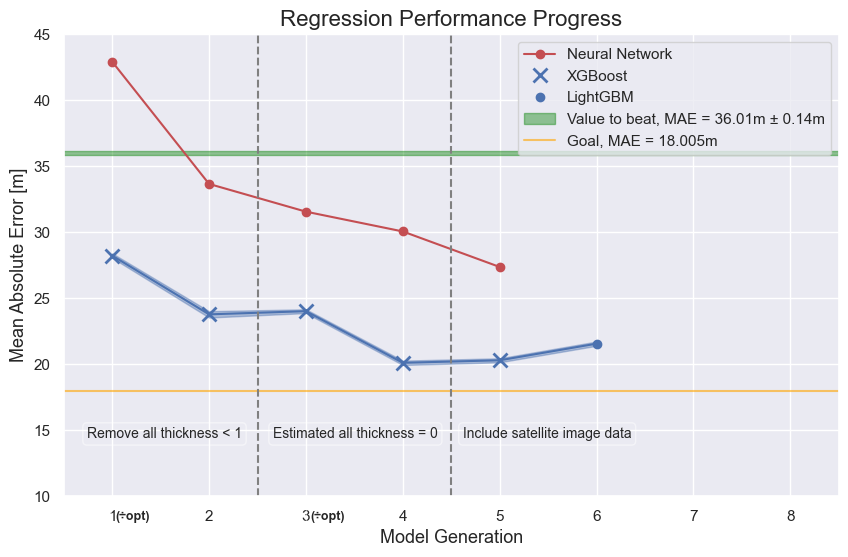

In [ ]:
# Plot the measurements
fig, ax = plt.subplots(figsize = (10, 6))

#Neural Network plot
plt.plot((1, 2, 3, 4, 5), MAE_nn[:5],  '-o', label = 'Neural Network', color = 'r')

#XGBoost plot
plt.plot(np.arange(len(MAE_dt[:6, 0])) + 1, MAE_dt[:6, 0], '-', color = 'b')
plt.plot((1, 2, 3, 4, 5), xg_dt[:5, 0], 'x', markersize = 10, markeredgewidth=2, label = 'XGBoost', color = 'b')
#LightGBM plot
plt.plot(6, lg_dt[0, 0], 'o', label = 'LightGBM', color = 'b')

plt.fill_between((1, 2, 3, 4, 5, 6), bounds(MAE_dt, 6)[0], bounds(MAE_dt, 6)[1], color='b', alpha=0.4)

# # Use fill_between to create the shaded error area
plt.fill_between(np.linspace(0, 9, 100), min_nicolo, max_nicolo, color='green', alpha=0.4, label = f'Value to beat, MAE = {MAE_nicolo[0]}m \u00B1 {MAE_nicolo[1]}m')
plt.axhline(MAE_nicolo[0] / 2, color = 'orange', alpha = 0.6, label = f'Goal, MAE = {MAE_nicolo[0] / 2}m')

plt.axvline(2.5, linestyle = '--', color = 'grey')
plt.axvline(4.5, linestyle = '--', color = 'grey')

textstr1 = 'Remove all thickness < 1'
props = dict(boxstyle='round', facecolor='none', alpha=0.5)
ax.text(0.03, 0.15, textstr1, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# Add the second textbox
textstr2 = 'Estimated all thickness = 0'
ax.text(0.27, 0.15, textstr2, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# Add the second textbox
textstr3 = 'Include satellite image data'
ax.text(0.515, 0.15, textstr3, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

textstropt = '(÷opt)'
ax.text(0.066, -0.03, textstropt, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props, fontweight='bold')
ax.text(0.318, -0.03, textstropt, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props, fontweight='bold')

# Show the plot
plt.legend()
plt.xlim(0.5, 8.5)
plt.ylim(10, 45)
plt.xticks(range(1, len(MAE_dt) + 1))
plt.xlabel('Model Generation', size = 13)
plt.ylabel('Mean Absolute Error [m]', size = 13)
plt.title('Regression Performance Progress', size = 16)
plt.savefig('performance_progress_3.png', dpi = 300);

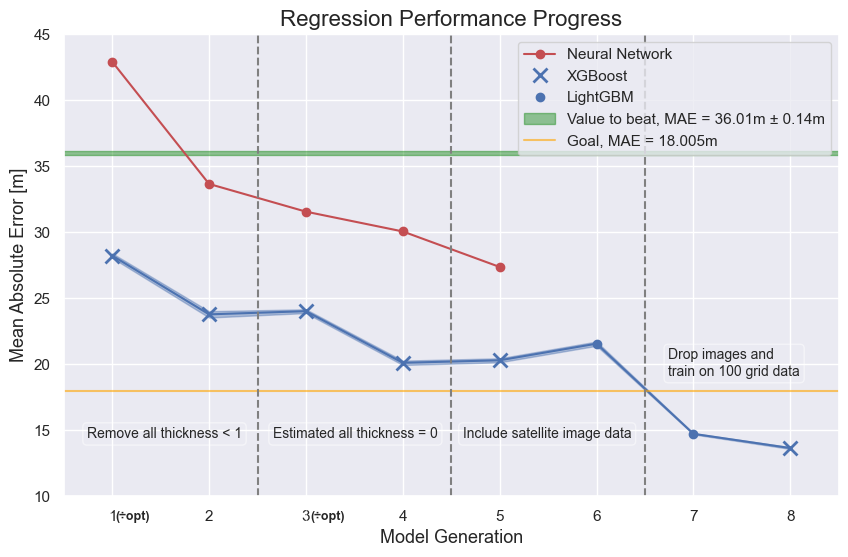

In [ ]:
# Plot the measurements
fig, ax = plt.subplots(figsize = (10, 6))

#Neural Network plot
plt.plot(np.arange(len(MAE_nn)) + 1, MAE_nn,  '-o', label = 'Neural Network', color = 'r')

#XGBoost plot
plt.plot(np.arange(len(MAE_dt[:, 0])) + 1, MAE_dt[:, 0], '-', color = 'b')
plt.plot((1, 2, 3, 4, 5, 8), xg_dt[:, 0], 'x', markersize = 10, markeredgewidth=2, label = 'XGBoost', color = 'b')

#LightGBM plot
plt.plot((6, 7), lg_dt[:, 0], 'o', label = 'LightGBM', color = 'b')
plt.fill_between(np.arange(len(MAE_dt)) + 1, lower_bound, upper_bound, color='b', alpha=0.4)

# Use fill_between to create the shaded error area
plt.fill_between(np.linspace(0, 9, 100), min_nicolo, max_nicolo, color='green', alpha=0.4, label = f'Value to beat, MAE = {MAE_nicolo[0]}m \u00B1 {MAE_nicolo[1]}m')
plt.axhline(MAE_nicolo[0] / 2, color = 'orange', alpha = 0.6, label = f'Goal, MAE = {MAE_nicolo[0] / 2}m')

# Sections
plt.axvline(2.5, linestyle = '--', color = 'grey')
plt.axvline(4.5, linestyle = '--', color = 'grey')
plt.axvline(6.5, linestyle = '--', color = 'grey')

textstr1 = 'Remove all thickness < 1'
props = dict(boxstyle='round', facecolor='none', alpha=0.5)
ax.text(0.03, 0.15, textstr1, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# Add the second textbox
textstr2 = 'Estimated all thickness = 0'
ax.text(0.27, 0.15, textstr2, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# Add the second textbox
textstr3 = 'Include satellite image data'
ax.text(0.515, 0.15, textstr3, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# Add the second textbox
textstr4 = 'Drop images and \ntrain on 100 grid data'
ax.text(0.78, 0.32, textstr4, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

textstropt = '(÷opt)'
ax.text(0.066, -0.03, textstropt, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props, fontweight='bold')
ax.text(0.318, -0.03, textstropt, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props, fontweight='bold')

# Show the plot
plt.legend()
plt.xlim(0.5, 8.5)
plt.ylim(10, 45)
plt.xticks(range(1, len(MAE_dt) + 1))
plt.xlabel('Model Generation', size = 13)
plt.ylabel('Mean Absolute Error [m]', size = 13)
plt.title('Regression Performance Progress', size = 16)
plt.savefig('performance_progress_4.png', dpi = 300);